## Importy 

In [5]:
import pandas as pd 
from features import extract_features
from modelsUnet import UNet, predict_masks, preprocess_image, test_model
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from dataset import train_loader, val_loader, test_loader
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib

## UNet Model 

In [6]:
model = UNet(in_channels=3, out_channels=2)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.load_state_dict(torch.load(r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\models_paths\unet\unet_cell_nucleus_0208.pth"))
model.to(device)

UNet(
  (encoder1): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (encoder2): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (encoder3): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): Re

# TRAIN I TEST SET

In [7]:
df1 = pd.read_csv(r'C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\features_train.csv')
df2 = pd.read_csv(r'C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\features_val.csv')
df_test = pd.read_csv(r'C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\features_test.csv')
df_train = pd.concat([df1, df2], ignore_index=True)


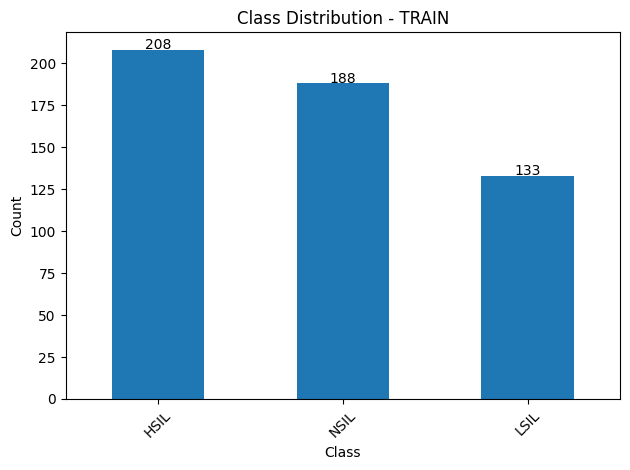

In [8]:
df_train = df_train[df_train['N'] != 0]
df_train['class'].value_counts().plot(kind='bar')
plt.title('Class Distribution - TRAIN')
plt.xlabel('Class')
plt.ylabel('Count')
for i, v in enumerate(df_train['class'].value_counts()):
    plt.text(i, v + 0.3, str(v), ha='center')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

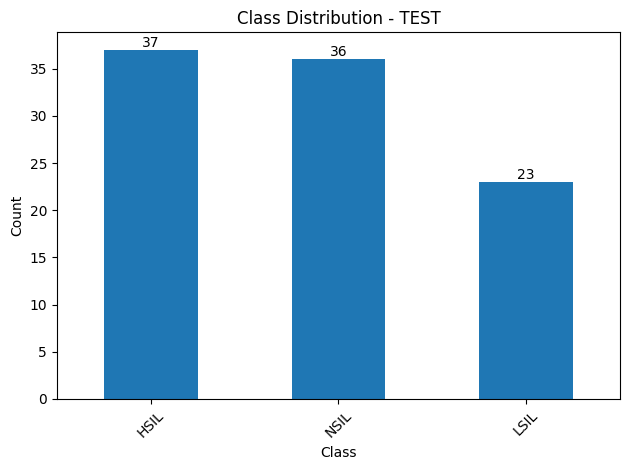

In [9]:
df_test = df_test[df_test['N'] != 0]
df_test['class'].value_counts().plot(kind='bar')
plt.title('Class Distribution - TEST')
plt.xlabel('Class')
plt.ylabel('Count')
for i, v in enumerate(df_test['class'].value_counts()):
    plt.text(i, v + 0.3, str(v), ha='center')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
df_train.head()

,N,C,NCr,Np,Cp,NCp,MinA,MinAr,MaxA,MaxAr,...,NSol,CSol,NCs,EqN,EqC,NCEq,OrN,OrC,NCOr,class
0,6378,14898,0.428111,396.190905,594.274166,0.666680,61.273155,0.703130,149.482440,0.606072,...,0.950168,0.987997,0.961711,90.115048,137.726986,0.654302,-0.228032,-0.097290,2.343838,HSIL
1,6557,12602,0.520314,412.374670,492.801077,0.836797,62.680798,0.716702,153.808322,0.744296,...,0.943385,1.000556,0.942861,91.370847,126.670299,0.721328,5.439876,-4829.849982,-0.001126,HSIL
2,1353,3288,0.411496,175.396968,298.409161,0.587773,23.428492,0.654546,76.295478,0.613176,...,1.009701,0.991706,1.018146,41.505338,64.702485,0.641480,-0.342323,-0.492934,0.694461,HSIL
3,1357,2554,0.531323,180.066016,233.078207,0.772556,23.426064,0.697542,74.652528,0.759039,...,0.991959,0.999609,0.992347,41.566646,57.025028,0.728919,-3.104588,-9.747040,0.318516,HSIL
4,14851,41568,0.357270,604.256921,913.879285,0.661200,117.153717,0.648408,204.658252,0.626758,...,0.922652,0.979927,0.941552,137.509565,230.056561,0.597721,-2.107840,5.487555,-0.384113,HSIL


In [11]:
df_train.shape

(529, 26)

In [15]:
X_train, y_train = df_train.drop(columns=["class"]), df_train["class"]
X_test,  y_test  = df_test.drop(columns=["class"]),  df_test["class"]

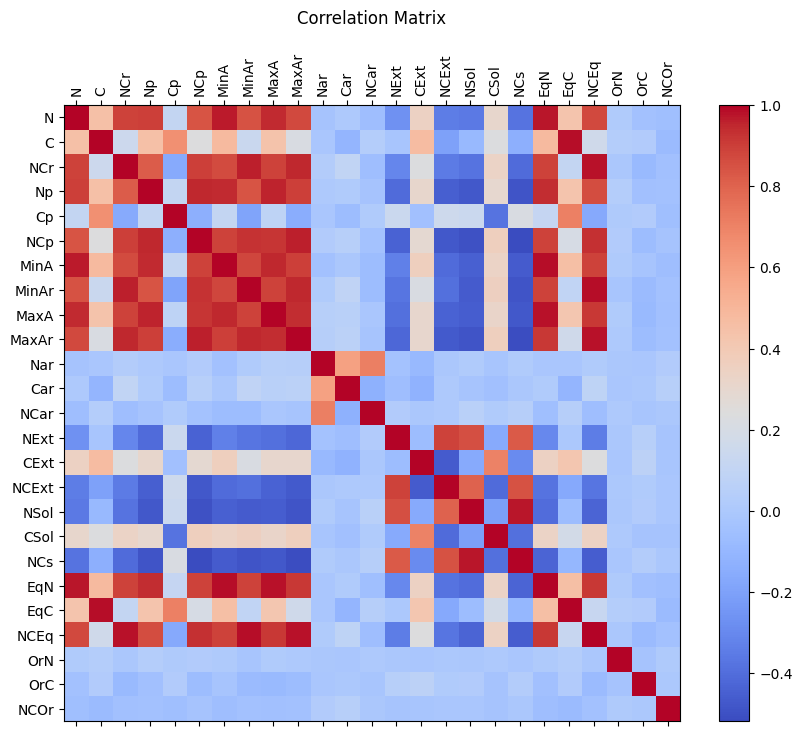

In [109]:
corr = df_train[['N', 'C', 'NCr', 'Np', 'Cp', 'NCp', 'MinA', 'MinAr', 'MaxA', 'MaxAr',
       'Nar', 'Car', 'NCar', 'NExt', 'CExt', 'NCExt', 'NSol', 'CSol', 'NCs',
       'EqN', 'EqC', 'NCEq', 'OrN', 'OrC', 'NCOr']].corr()

fig, ax = plt.subplots(figsize=(10, 8))
cax = ax.matshow(corr, cmap="coolwarm")  # możesz zmienić cmap
fig.colorbar(cax)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)

plt.title("Correlation Matrix", pad=20)
plt.show()

## Uczenie z KFold i GridSearch (scalar i smote w pipeline - aby nie było wycieku danych)

In [110]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipe_svm = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("clf", SVC(probability=True, random_state=42))
])

pipe_mlp = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("clf", MLPClassifier(solver="adam", random_state=42, max_iter=1000))
])

pipe_rf = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("clf", RandomForestClassifier(random_state=42))
])

pipe_xgb = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("clf", XGBClassifier(
        eval_metric="logloss",
        use_label_encoder=False,
        random_state=42,
        n_jobs=-1
    ))
])

pipe_lgbm = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("clf", LGBMClassifier(random_state=42))
])

pipelines = {
    "SVM": pipe_svm,
    "NeuralNet": pipe_mlp,
    "RandomForest": pipe_rf,
    "XGBoost": pipe_xgb,
    "LightGBM": pipe_lgbm
}

param_grids = {
    "SVM": {
        "clf__C": [0.01, 0.1, 1, 10, 100],
        "clf__gamma": ["scale", 1, 0.1, 0.01, 0.001],
        "clf__kernel": ["rbf", "poly", "sigmoid"]
    },
    "NeuralNet": {
        "clf__hidden_layer_sizes": [(32, 16), (64, 32), (128, 64), (128, 64, 32)],
        "clf__activation": ["relu", "tanh", "logistic"],
        "clf__batch_size": [32, 64, 16],
        "clf__alpha": [1e-4, 1e-3, 1e-2],
        "clf__learning_rate_init": [1e-3, 1e-2], 
        "clf__n_iter_no_change": [10, 20],
        "clf__max_iter": [300, 600, 1000],
    },
    "RandomForest": {
        "clf__n_estimators": [100, 200, 500],
        "clf__max_depth": [None, 10, 20, 30],
        "clf__min_samples_split": [2, 5, 10],
        "clf__min_samples_leaf": [1, 2, 4]
    },
    "XGBoost": {
        "clf__n_estimators": [100, 200, 300],
        "clf__max_depth": [3, 5, 7],
        "clf__learning_rate": [0.01, 0.1, 0.2],
        "clf__subsample": [0.8, 1.0],
        "clf__colsample_bytree": [0.8, 1.0]
        # Alternatywa dla SMOTE: clf__scale_pos_weight (gdy duża nierównowaga)
    },
    "LightGBM": {
        "clf__n_estimators": [100, 200, 300],
        "clf__max_depth": [-1, 10, 20],
        "clf__learning_rate": [0.01, 0.1, 0.2],
        "clf__num_leaves": [31, 50, 100],
        "clf__subsample": [0.8, 1.0],
        "clf__colsample_bytree": [0.8, 1.0],
        "clf__min_child_samples": [10, 20, 50],
    }
}

In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(y_train) 

y_train_enc = le.transform(y_train)
y_test_enc  = le.transform(y_test)

In [112]:
results = []
for name, pipe in pipelines.items():
    print(f"\n=== GridSearch dla {name} ===")
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grids[name],
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        verbose=2,
        refit=True  
    )
    grid.fit(X_train, y_train_enc)

    best_model = grid.best_estimator_
    best_params = grid.best_params_

    y_test_pred_enc = best_model.predict(X_test)
    y_test_pred = le.inverse_transform(y_test_pred_enc)

    results.append({
        "Model": name,
        "Split": "Test",
        "Best_Params": best_params,
        "Accuracy": accuracy_score(y_test, y_test_pred),
        "Precision": precision_score(y_test, y_test_pred, average="macro", zero_division=0),
        "Recall": recall_score(y_test, y_test_pred, average="macro", zero_division=0),
        "F1": f1_score(y_test, y_test_pred, average="macro", zero_division=0)
    })

    joblib.dump({"model": best_model, "label_encoder": le}, f"models_paths/best_model_{name}4.pkl")


results = pd.DataFrame(results).sort_values("F1", ascending=False)
print("\n=== Results ===")
print(results)



=== GridSearch dla SVM ===
Fitting 5 folds for each of 75 candidates, totalling 375 fits

=== GridSearch dla NeuralNet ===
Fitting 5 folds for each of 1296 candidates, totalling 6480 fits


c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(



=== GridSearch dla RandomForest ===
Fitting 5 folds for each of 108 candidates, totalling 540 fits

=== GridSearch dla XGBoost ===
Fitting 5 folds for each of 108 candidates, totalling 540 fits


c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:21:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== GridSearch dla LightGBM ===
Fitting 5 folds for each of 972 candidates, totalling 4860 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000594 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5216
[LightGBM] [Info] Number of data points in the train set: 624, number of used features: 25
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

=== Results ===
          Model Split                                        Best_Params  \
1     NeuralNet  Test  {'clf__activation': 'logistic', 'clf__alpha': ...   
4      LightGBM  Test  {'clf__colsample_bytree': 0.8, 'clf__

In [113]:
results.to_csv("classification_results.csv", index=False)

In [114]:
results

,Model,Split,Best_Params,Accuracy,Precision,Recall,F1
1,NeuralNet,Test,"{'clf__activation': 'logistic', 'clf__alpha': ...",0.864583,0.861953,0.871665,0.857265
4,LightGBM,Test,"{'clf__colsample_bytree': 0.8, 'clf__learning_...",0.812500,0.794407,0.798951,0.795195
3,XGBoost,Test,"{'clf__colsample_bytree': 1.0, 'clf__learning_...",0.802083,0.785254,0.789692,0.785724
0,SVM,Test,"{'clf__C': 10, 'clf__gamma': 'scale', 'clf__ke...",0.760417,0.754444,0.753155,0.749791
2,RandomForest,Test,"{'clf__max_depth': None, 'clf__min_samples_lea...",0.760417,0.749022,0.753406,0.746523


In [115]:
from sklearn import clone


final_model = clone(best_model)
final_model.fit(X_train, y_train_enc)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000316 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5216
[LightGBM] [Info] Number of data points in the train set: 624, number of used features: 25
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


Pipeline(steps=[('smote', SMOTE(random_state=42)),
                ('clf',
                 LGBMClassifier(colsample_bytree=0.8, learning_rate=0.01,
                                min_child_samples=10, n_estimators=200,
                                random_state=42, subsample=0.8))])

In [12]:

def predict(pipe, label_encoder, input_features):
    feature_names = ['N', 'C', 'NCr', 'Np', 'Cp', 'NCp', 'MinA', 'MinAr', 'MaxA', 'MaxAr', 'Nar', 'Car', 'NCar', 'NExt', 'CExt', 'NCExt', 'NSol', 'CSol', 'NCs', 'EqN', 'EqC', 'NCEq', 'OrN', 'OrC', 'NCOr']
    try:
        X_new = pd.DataFrame([[input_features[feat] for feat in feature_names]], columns=feature_names)
    except KeyError as e:
        raise ValueError(f"Brakuje cechy w słowniku: {e}")

    y_pred_encoded = pipe.predict(X_new)
    predicted_class = label_encoder.inverse_transform(y_pred_encoded)[0]

    return predicted_class


In [118]:
classifier = joblib.load(r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\models_paths\best_model_NeuralNet4.pkl")
label_encoder = classifier["label_encoder"]
pipe = classifier["model"]


In [119]:
pil_image, input_tensor = preprocess_image(r'C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\test\LSIL\1b_1_aug0.png')
predicted_masks = predict_masks(model, input_tensor, device, threshold_nuclei=0.2, threshold_cell=0.5)
cell_mask = predicted_masks[0]
nucleus_mask = predicted_masks[1]
features = extract_features(nucleus_mask, cell_mask)
print("Extracted features:", features)
predicted_class = predict(pipe, label_encoder, input_features=features)
print("Predicted class:", predicted_class)

Extracted features: {'N': np.uint64(7086), 'C': np.uint64(37887), 'NCr': np.float64(0.18702985192810198), 'Np': 324.29141092300415, 'Cp': 858.7493418455124, 'NCp': 0.377632208982052, 'MinA': 80.95867156982422, 'MinAr': 0.4499491341181842, 'MaxA': np.float64(108.57716150277645), 'MaxAr': np.float64(0.38110154626713943), 'Nar': 0.9393939393939394, 'Car': 0.92578125, 'NCar': 1.0147040020457743, 'NExt': np.float64(0.7696318018898664), 'CExt': np.float64(0.6244560917721519), 'NCExt': np.float64(1.2324834556513309), 'NSol': np.float64(1.038698328935796), 'CSol': np.float64(0.9335797449639623), 'NCs': np.float64(1.1125973271580474), 'EqN': np.float64(94.98513259449273), 'EqC': np.float64(219.63430203722987), 'NCEq': np.float64(0.4324694809210264), 'OrN': np.float64(-7.186521930228615), 'OrC': np.float64(-10.375873882964356), 'NCOr': np.float64(0.6926184735174756)}
Predicted class: LSIL


In [120]:
pil_image, input_tensor = preprocess_image(r'C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\test\NSIL\22c_1.bmp')
predicted_masks = predict_masks(model, input_tensor, device, threshold_nuclei=0.2, threshold_cell=0.5)
cell_mask = predicted_masks[0]
nucleus_mask = predicted_masks[1]
features = extract_features(nucleus_mask, cell_mask)
print("Extracted features:", features)
predicted_class = predict(pipe, label_encoder, input_features=features)
print("Predicted class:", predicted_class)

Extracted features: {'N': np.uint64(451), 'C': np.uint64(28510), 'NCr': np.float64(0.015819010873377764), 'Np': 77.69848418235779, 'Cp': 818.2640600204468, 'NCp': 0.09495526930562764, 'MinA': 20.0, 'MinAr': 0.10188354593791907, 'MaxA': np.float64(26.92582403567252), 'MaxAr': np.float64(0.12398212734070096), 'Nar': 1.2380952380952381, 'Car': 0.9801980198019802, 'NCar': 1.263107263107263, 'NExt': np.float64(0.826007326007326), 'CExt': np.float64(0.7128212821282128), 'NCExt': np.float64(1.1587860052960017), 'NSol': np.float64(1.0636792452830188), 'CSol': np.float64(0.9230569990125136), 'NCs': np.float64(1.1523440550485429), 'EqN': np.float64(23.96311821686732), 'EqC': np.float64(190.52574477062015), 'NCEq': np.float64(0.125773649360181), 'OrN': np.float64(0.6174438538173612), 'OrC': np.float64(-1.9189982949348015), 'NCOr': np.float64(-0.32175320605917423)}
Predicted class: NSIL


In [121]:
pil_image, input_tensor = preprocess_image(r'C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\val\HSIL\2b_1.jpg')
predicted_masks = predict_masks(model, input_tensor, device, threshold_nuclei=0.2, threshold_cell=0.5)
cell_mask = predicted_masks[0]
nucleus_mask = predicted_masks[1]
features = extract_features(nucleus_mask, cell_mask)
print("Extracted features:", features)
predicted_class = predict(pipe, label_encoder, input_features=features)
print("Predicted class:", predicted_class)

Extracted features: {'N': np.uint64(17306), 'C': np.uint64(44893), 'NCr': np.float64(0.38549439779030137), 'Np': 659.2518683671951, 'Cp': 814.4823170900345, 'NCp': 0.8094121315273688, 'MinA': 126.82635498046875, 'MinAr': 0.5467992506625384, 'MaxA': np.float64(194.94101672044292), 'MaxAr': np.float64(0.683986725869078), 'Nar': 0.7864583333333334, 'Car': 0.995850622406639, 'NCar': 0.7897352430555555, 'NExt': np.float64(0.5969232891832229), 'CExt': np.float64(0.77615836791148), 'NCExt': np.float64(0.7690740883068098), 'NSol': np.float64(0.9169227508742185), 'CSol': np.float64(1.0004568499637863), 'NCs': np.float64(0.916504046033978), 'EqN': np.float64(148.4408419579555), 'EqC': np.float64(239.0806200464514), 'NCEq': np.float64(0.6208819515739699), 'OrN': np.float64(0.7013970988453097), 'OrC': np.float64(14.2163906145489), 'NCOr': np.float64(0.04933721349267848)}
Predicted class: HSIL


In [122]:
features = {'N': np.uint64(4439), 'C': np.uint64(262118), 'NCr': np.float64(0.016935120823445927), 'Np': 277.49747383594513, 'Cp': 2309.796025156975, 'NCp': 0.12013938495590158, 'MinA': 73.0, 'MinAr': 0.12784588441331, 'MaxA': np.float64(83.35466393669883), 'MaxAr': np.float64(0.12441202480634707), 'Nar': 1.0405405405405406, 'Car': 1.0367132867132867, 'NCar': 1.0036917187001504, 'NExt': np.float64(0.7790452790452791), 'CExt': np.float64(0.772762650502954), 'NCExt': np.float64(1.008130088246677), 'NSol': np.float64(0.9855683836589698), 'CSol': np.float64(0.9516233848745476), 'NCs': np.float64(1.0356706227736272), 'EqN': np.float64(75.17918820444517), 'EqC': np.float64(577.7014825901795), 'NCEq': np.float64(0.13013500998365476), 'OrN': np.float64(1.446102061602086), 'OrC': np.float64(4.140502931377116), 'NCOr': np.float64(0.349257586715708)}
predicted_class = predict(pipe, label_encoder, input_features=features)
print("Predicted class:", predicted_class)

Predicted class: NSIL


In [24]:
from sklearn.calibration import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

def plot_multiclass_roc(model, label_encoder, classes, X_test, y_test, title="ROC Curve"):
    y_proba = model.predict_proba(X_test)  
    y_true_enc = label_encoder.transform(y_test)               
    plt.figure(figsize=(8, 6))
    n_classes = len(classes)

    y_true_bin = label_binarize(y_true_enc, classes=np.arange(n_classes))

    macro_auc = roc_auc_score(y_true_bin, y_proba, multi_class="ovr", average="macro")
    print(f"Macro AUC (OvR): {macro_auc:.4f}")

    plt.figure(figsize=(8, 6))
    for i, cls in enumerate(classes):
        if y_true_bin[:, i].sum() == 0:
            continue
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
        cls_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{cls} (AUC = {cls_auc:.2f})")

    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(y_true, y_pred, classes, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=False)
    plt.title(title)
    plt.show()


def print_classification_metrics(y_true, y_pred, classes, title="Classification Metrics"):
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
    acc = accuracy_score(y_true, y_pred)
    prec_macro = precision_score(y_true, y_pred, labels=classes, average="macro", zero_division=0)
    rec_macro = recall_score(y_true, y_pred, labels=classes, average="macro", zero_division=0)
    f1_macro = f1_score(y_true, y_pred, labels=classes, average="macro", zero_division=0)
    print(f"\n=== {title} ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision (macro): {prec_macro:.4f}")
    print(f"Recall (macro):    {rec_macro:.4f}")
    print(f"F1 (macro):        {f1_macro:.4f}")
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, labels=classes, digits=4))

def evaluate(model_class):
    import os
    from sklearn.metrics import accuracy_score, precision_recall_fscore_support, precision_score, recall_score, f1_score, classification_report

    y_true = []
    y_pred = []
    label_encoder = model_class["label_encoder"]
    pipe = model_class["model"]
    folder = r'C:\Users\aleks\OneDrive\Documents\inzynierka\data\TEST'
    for subfolder in os.listdir(folder):
        true_class = os.path.basename(subfolder)
        for filename in os.listdir(os.path.join(folder, subfolder)):
            if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
                image_path = os.path.join(folder, subfolder, filename)
                pil_image, input_tensor = preprocess_image(image_path)
                predicted_masks = predict_masks(model, input_tensor, device, threshold_nuclei=0.2, threshold_cell=0.5)
                cell_mask = predicted_masks[0]
                nucleus_mask = predicted_masks[1]
                features = extract_features(nucleus_mask, cell_mask)
                predicted_class = predict(pipe, label_encoder, input_features=features)
                y_true.append(true_class)
                y_pred.append(predicted_class)


    acc = accuracy_score(y_true, y_pred)
    prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, labels=label_encoder.classes_, average="macro", zero_division=0
        )
    prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(
            y_true, y_pred, labels=label_encoder.classes_, average="weighted", zero_division=0
        )

    print("\n=== METRYKI (global) ===")
    print(f"Accuracy:            {acc:.4f}")
    print(f"Precision (macro):   {prec_macro:.4f}")
    print(f"Recall    (macro):   {rec_macro:.4f}")
    print(f"F1        (macro):   {f1_macro:.4f}")
    print(f"Precision (weighted):{prec_weighted:.4f}")
    print(f"Recall    (weighted):{rec_weighted:.4f}")
    print(f"F1        (weighted):{f1_weighted:.4f}")

    print("\n=== RAPORT (per klasa) ===")
    print(classification_report(y_true, y_pred, labels=label_encoder.classes_, digits=4))

    cm = confusion_matrix(y_true, y_pred, labels=label_encoder.classes_, normalize='true')
    cm_df = pd.DataFrame(
            cm,
            index=[f"true_{l}" for l in label_encoder.classes_],
            columns=[f"pred_{l}" for l in label_encoder.classes_],
        )
    print("\n=== CONFUSION MATRIX (znormalizowana, wartości 0–1) ===")
    print(cm_df)



    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.set_title("Confusion Matrix (HSIL/LSIL/NSIL, normalized)")
    tick_marks = np.arange(len(label_encoder.classes_))
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.set_xticklabels(label_encoder.classes_)
    ax.set_yticklabels(label_encoder.classes_)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center", color="black")

    ax.set_ylabel("True class")
    ax.set_xlabel("Predicted class")
    fig.tight_layout()
    plt.close()

## NN

In [13]:
model_class = joblib.load(r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\models_paths\best_model_NeuralNet4.pkl")

In [18]:
y_test_pred = model_class["model"].predict(X_test)
y_test_pred = le.inverse_transform(y_test_pred)
label_encoder = model_class["label_encoder"]
classes = list(label_encoder.classes_)

NameError: name 'le' is not defined

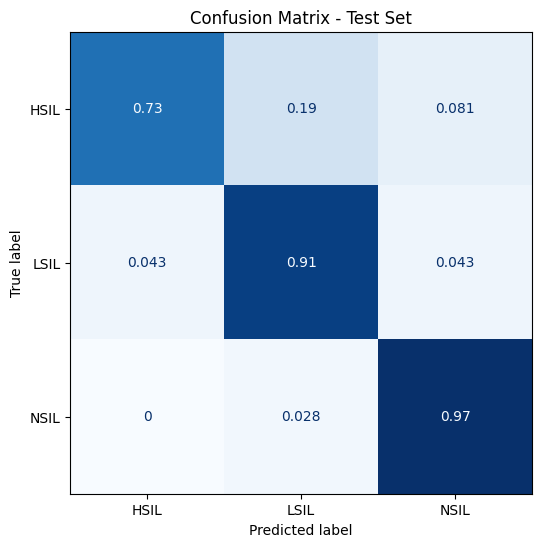

In [126]:
plot_confusion_matrix(y_test, y_test_pred, classes, title="Confusion Matrix - Test Set")

In [127]:
print_classification_metrics(y_test, y_test_pred, classes)


=== Classification Metrics ===
Accuracy:  0.8646
Precision (macro): 0.8620
Recall (macro):    0.8717
F1 (macro):        0.8573

Classification report:
              precision    recall  f1-score   support

        HSIL     0.9643    0.7297    0.8308        37
        LSIL     0.7241    0.9130    0.8077        23
        NSIL     0.8974    0.9722    0.9333        36

    accuracy                         0.8646        96
   macro avg     0.8620    0.8717    0.8573        96
weighted avg     0.8817    0.8646    0.8637        96



In [128]:
evaluate(model_class)


=== METRYKI (global) ===
Accuracy:            0.7241
Precision (macro):   0.7247
Recall    (macro):   0.7315
F1        (macro):   0.7248
Precision (weighted):0.7218
Recall    (weighted):0.7241
F1        (weighted):0.7198

=== RAPORT (per klasa) ===
              precision    recall  f1-score   support

        HSIL     0.7647    0.6500    0.7027        20
        LSIL     0.6000    0.6000    0.6000        20
        NSIL     0.8095    0.9444    0.8718        18

    accuracy                         0.7241        58
   macro avg     0.7247    0.7315    0.7248        58
weighted avg     0.7218    0.7241    0.7198        58


=== CONFUSION MATRIX (znormalizowana, wartości 0–1) ===
           pred_HSIL  pred_LSIL  pred_NSIL
true_HSIL       0.65   0.350000   0.000000
true_LSIL       0.20   0.600000   0.200000
true_NSIL       0.00   0.055556   0.944444


Macro AUC (OvR): 0.9389


<Figure size 800x600 with 0 Axes>

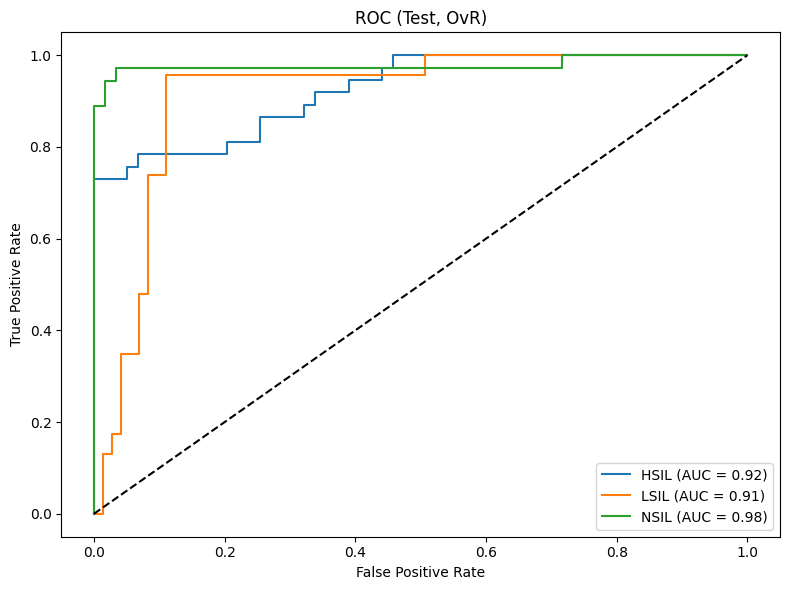

In [129]:
plot_multiclass_roc(model_class['model'], model_class["label_encoder"], classes, X_test, y_test, title="ROC (Test, OvR)")


## XGBOOST

In [130]:
model_class = joblib.load(r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\models_paths\best_model_XGBoost4.pkl")


In [131]:
y_test_pred = model_class["model"].predict(X_test)
y_test_pred = le.inverse_transform(y_test_pred)
label_encoder = model_class["label_encoder"]
classes = list(label_encoder.classes_)

In [132]:
evaluate(model_class)


=== METRYKI (global) ===
Accuracy:            0.5690
Precision (macro):   0.5774
Recall    (macro):   0.5722
F1        (macro):   0.5739
Precision (weighted):0.5744
Recall    (weighted):0.5690
F1        (weighted):0.5707

=== RAPORT (per klasa) ===
              precision    recall  f1-score   support

        HSIL     0.6111    0.5500    0.5789        20
        LSIL     0.4545    0.5000    0.4762        20
        NSIL     0.6667    0.6667    0.6667        18

    accuracy                         0.5690        58
   macro avg     0.5774    0.5722    0.5739        58
weighted avg     0.5744    0.5690    0.5707        58


=== CONFUSION MATRIX (znormalizowana, wartości 0–1) ===
           pred_HSIL  pred_LSIL  pred_NSIL
true_HSIL   0.550000   0.450000   0.000000
true_LSIL   0.200000   0.500000   0.300000
true_NSIL   0.166667   0.166667   0.666667


## LIGHT GBM

In [25]:
model_class = joblib.load(r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\models_paths\best_model_LightGBM4.pkl")

In [26]:
y_test_pred = model_class["model"].predict(X_test)
y_test_pred = le.inverse_transform(y_test_pred)
label_encoder = model_class["label_encoder"]
classes = list(label_encoder.classes_)

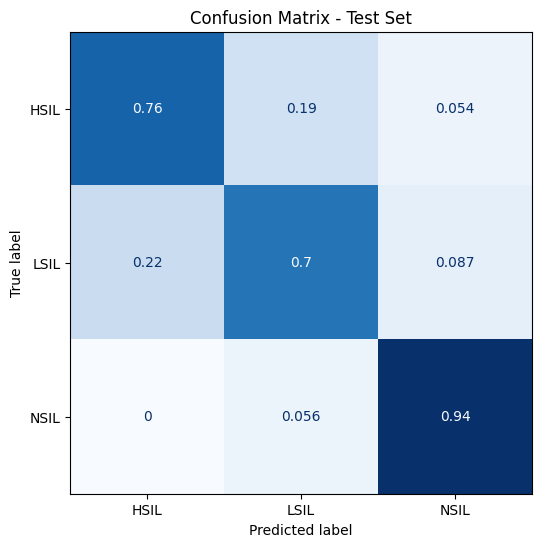

In [27]:
plot_confusion_matrix(y_test, y_test_pred, classes, title="Confusion Matrix - Test Set")

In [28]:
print_classification_metrics(y_test, y_test_pred, classes)


=== Classification Metrics ===
Accuracy:  0.8125
Precision (macro): 0.7944
Recall (macro):    0.7990
F1 (macro):        0.7952

Classification report:
              precision    recall  f1-score   support

        HSIL     0.8485    0.7568    0.8000        37
        LSIL     0.6400    0.6957    0.6667        23
        NSIL     0.8947    0.9444    0.9189        36

    accuracy                         0.8125        96
   macro avg     0.7944    0.7990    0.7952        96
weighted avg     0.8159    0.8125    0.8127        96



In [136]:
evaluate(model_class)


=== METRYKI (global) ===
Accuracy:            0.6034
Precision (macro):   0.5985
Recall    (macro):   0.6130
F1        (macro):   0.6016
Precision (weighted):0.5940
Recall    (weighted):0.6034
F1        (weighted):0.5948

=== RAPORT (per klasa) ===
              precision    recall  f1-score   support

        HSIL     0.6471    0.5500    0.5946        20
        LSIL     0.4211    0.4000    0.4103        20
        NSIL     0.7273    0.8889    0.8000        18

    accuracy                         0.6034        58
   macro avg     0.5985    0.6130    0.6016        58
weighted avg     0.5940    0.6034    0.5948        58


=== CONFUSION MATRIX (znormalizowana, wartości 0–1) ===
           pred_HSIL  pred_LSIL  pred_NSIL
true_HSIL       0.55   0.450000   0.000000
true_LSIL       0.30   0.400000   0.300000
true_NSIL       0.00   0.111111   0.888889


In [137]:
model_class = joblib.load(r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\models_paths\best_model_SVM4.pkl")
evaluate(model_class)


=== METRYKI (global) ===
Accuracy:            0.5862
Precision (macro):   0.6104
Recall    (macro):   0.5870
F1        (macro):   0.5941
Precision (weighted):0.6044
Recall    (weighted):0.5862
F1        (weighted):0.5909

=== RAPORT (per klasa) ===
              precision    recall  f1-score   support

        HSIL     0.5217    0.6000    0.5581        20
        LSIL     0.5238    0.5500    0.5366        20
        NSIL     0.7857    0.6111    0.6875        18

    accuracy                         0.5862        58
   macro avg     0.6104    0.5870    0.5941        58
weighted avg     0.6044    0.5862    0.5909        58


=== CONFUSION MATRIX (znormalizowana, wartości 0–1) ===
           pred_HSIL  pred_LSIL  pred_NSIL
true_HSIL   0.600000   0.400000   0.000000
true_LSIL   0.300000   0.550000   0.150000
true_NSIL   0.277778   0.111111   0.611111


In [138]:
model_class = joblib.load(r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\models_paths\best_model_RandomForest4.pkl")
evaluate(model_class)


=== METRYKI (global) ===
Accuracy:            0.5862
Precision (macro):   0.5932
Recall    (macro):   0.5926
F1        (macro):   0.5895
Precision (weighted):0.5895
Recall    (weighted):0.5862
F1        (weighted):0.5844

=== RAPORT (per klasa) ===
              precision    recall  f1-score   support

        HSIL     0.6250    0.5000    0.5556        20
        LSIL     0.4545    0.5000    0.4762        20
        NSIL     0.7000    0.7778    0.7368        18

    accuracy                         0.5862        58
   macro avg     0.5932    0.5926    0.5895        58
weighted avg     0.5895    0.5862    0.5844        58


=== CONFUSION MATRIX (znormalizowana, wartości 0–1) ===
           pred_HSIL  pred_LSIL  pred_NSIL
true_HSIL   0.500000   0.500000   0.000000
true_LSIL   0.200000   0.500000   0.300000
true_NSIL   0.111111   0.111111   0.777778


## SHAP dla LIGHTGBM

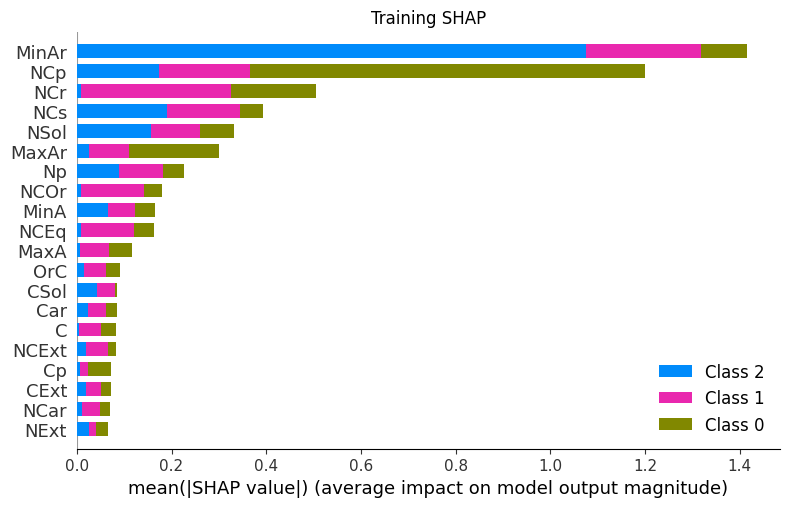

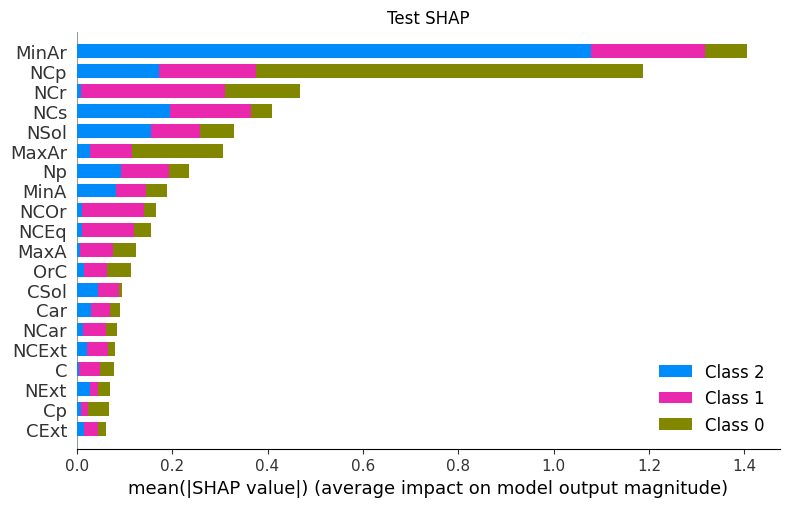

In [141]:
import shap

model_class = joblib.load(r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\models_paths\best_model_LightGBM4.pkl")
train_shap_values = shap.TreeExplainer(model_class["model"].named_steps["clf"]).shap_values(df_train.drop('class', axis=1))
test_shap_values = shap.TreeExplainer(model_class["model"].named_steps["clf"]).shap_values(X_test)

plt.subplot(2, 1, 1)
plt.title('Training SHAP')
shap.summary_plot(train_shap_values, df_train.drop('class', axis=1), plot_type="bar")

plt.subplot(2, 1, 2)
plt.title('Test SHAP')
shap.summary_plot(test_shap_values, X_test, plot_type="bar")

In [143]:
class_names = model_class["label_encoder"].classes_
print(class_names) 

['HSIL' 'LSIL' 'NSIL']


## LIME

In [145]:
import pandas as pd
import joblib
import numpy as np
from lime.lime_tabular import LimeTabularExplainer

model_class = joblib.load(r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\models_paths\best_model_LightGBM3.pkl")
label_encoder = model_class["label_encoder"]

TARGET = "class"
feature_names = list(df_train.drop(columns=[TARGET]).columns)

# 
X_train = df_train.drop(columns=[TARGET])
y_train = label_encoder.transform(df_train[TARGET])

df_test = df_test[df_test[TARGET].notna()].copy()
X_test = df_test.drop(columns=[TARGET])
y_test = label_encoder.transform(df_test[TARGET])

X_train_np = X_train.values
X_test_np  = X_test.values

explainer = LimeTabularExplainer(
    training_data=X_train_np,
    feature_names=feature_names,
    class_names=list(label_encoder.classes_),
    mode="classification",
    random_state=42
)


predict_fn = lambda data: model_class["model"].predict_proba(
    pd.DataFrame(data, columns=feature_names)
)




In [146]:
## LIME DLA NN 
import pandas as pd
import joblib
import numpy as np
from lime.lime_tabular import LimeTabularExplainer

model_class = joblib.load(r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\models_paths\best_model_NeuralNet4.pkl")
label_encoder = model_class["label_encoder"]

TARGET = "class"
feature_names = list(df_train.drop(columns=[TARGET]).columns)

# 
X_train = df_train.drop(columns=[TARGET])
y_train = label_encoder.transform(df_train[TARGET])

df_test = df_test[df_test[TARGET].notna()].copy()
X_test = df_test.drop(columns=[TARGET])
y_test = label_encoder.transform(df_test[TARGET])

X_train_np = X_train.values
X_test_np  = X_test.values

explainer = LimeTabularExplainer(
    training_data=X_train_np,
    feature_names=feature_names,
    class_names=list(label_encoder.classes_),
    mode="classification",
    random_state=42
)


predict_fn = lambda data: model_class["model"].predict_proba(
    pd.DataFrame(data, columns=feature_names)
)

In [147]:
features= {'N': np.uint64(17306), 'C': np.uint64(44893), 'NCr': np.float64(0.38549439779030137), 'Np': 659.2518683671951, 'Cp': 814.4823170900345, 'NCp': 0.8094121315273688, 'MinA': 126.82635498046875, 'MinAr': 0.5467992506625384, 'MaxA': np.float64(194.94101672044292), 'MaxAr': np.float64(0.683986725869078), 'Nar': 0.7864583333333334, 'Car': 0.995850622406639, 'NCar': 0.7897352430555555, 'NExt': np.float64(0.5969232891832229), 'CExt': np.float64(0.77615836791148), 'NCExt': np.float64(0.7690740883068098), 'NSol': np.float64(0.9169227508742185), 'CSol': np.float64(1.0004568499637863), 'NCs': np.float64(0.916504046033978), 'EqN': np.float64(148.4408419579555), 'EqC': np.float64(239.0806200464514), 'NCEq': np.float64(0.6208819515739699), 'OrN': np.float64(0.7013970988453097), 'OrC': np.float64(14.2163906145489), 'NCOr': np.float64(0.04933721349267848)}

row = features.values()
row = np.array(list(row))
len(row)

25

In [148]:
model_class["model"].predict_proba([row])

c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.80000753, 0.19238596, 0.00760651]])

In [149]:
exp = explainer.explain_instance(
    data_row=row,
    predict_fn=predict_fn, 
    top_labels=len(label_encoder.classes_))

exp.save_to_file("lime_explanation3.html")